<div align="center">

#
# Facultad de Ciencias Exactas, Ingenieria y Agrimensura
## Universidad Nacional de Rosario (UNR)


---


# Aprendizaje Automatico I


## Imputacion de Datos: KMeans para variables numericas, CatBoost para variables categoricas.


---
**Cuerpo Docente:** Giuliano Crenna, Agustín Alsop, Tomás Avecilla
---

## Indice

1. Carga del dataset
2. Analisis exploratorio de datos (EDA)
3. Diagnostico de valores faltantes
4. Tecnicas de imputacion
5. Imputacion numerica con KMeans
6. Imputacion categorica con CatBoost
7. Evaluacion experimental
8. Conclusiones

## 1. Carga del dataset

**Disclaimer:** El año pasado (2025) realicé un informe de este tópico, a los que les guste los aspectos mas teóricos se los recomiendo.

[Imputación de valores faltantes: Fundamentos teóricos y análisis experimental](https://drive.google.com/file/d/1qtpGeF6DKx6U6kBJK2a7P6gItFD5Uofl/view?usp=sharing)

Se trabaja con el dataset **Titanic**, accesible directamente desde
la libreria `seaborn` mediante `sns.load_dataset('titanic')`.
Contiene 891 pasajeros del RMS Titanic con 15 variables que
describen su perfil (edad, sexo, clase, tarifa, puerto de embarque,
etc.) y una variable objetivo `survived` que indica si la persona
sobrevivio al naufragio.

### 1.1 Instalacion de dependencias

Se incluye la instalacion explicita de CatBoost porque no forma
parte del stack estandar de conda / pip en muchas distribuciones.

In [ ]:
!pip install catboost

In [ ]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    mean_squared_error,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100
np.random.seed(RANDOM_STATE)

In [ ]:
raw_df = sns.load_dataset("titanic")
print(f"Shape: {raw_df.shape}")
raw_df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Analisis exploratorio de datos (EDA)

Antes de tocar los faltantes conviene entender como se reparten las
variables clave. La distribucion del target esta desbalanceada
(aproximadamente 62% no sobrevivio, 38% sobrevivio).

In [ ]:
raw_df.info()
print()
print(raw_df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

             count unique          top freq       mean        std   min  \
sur

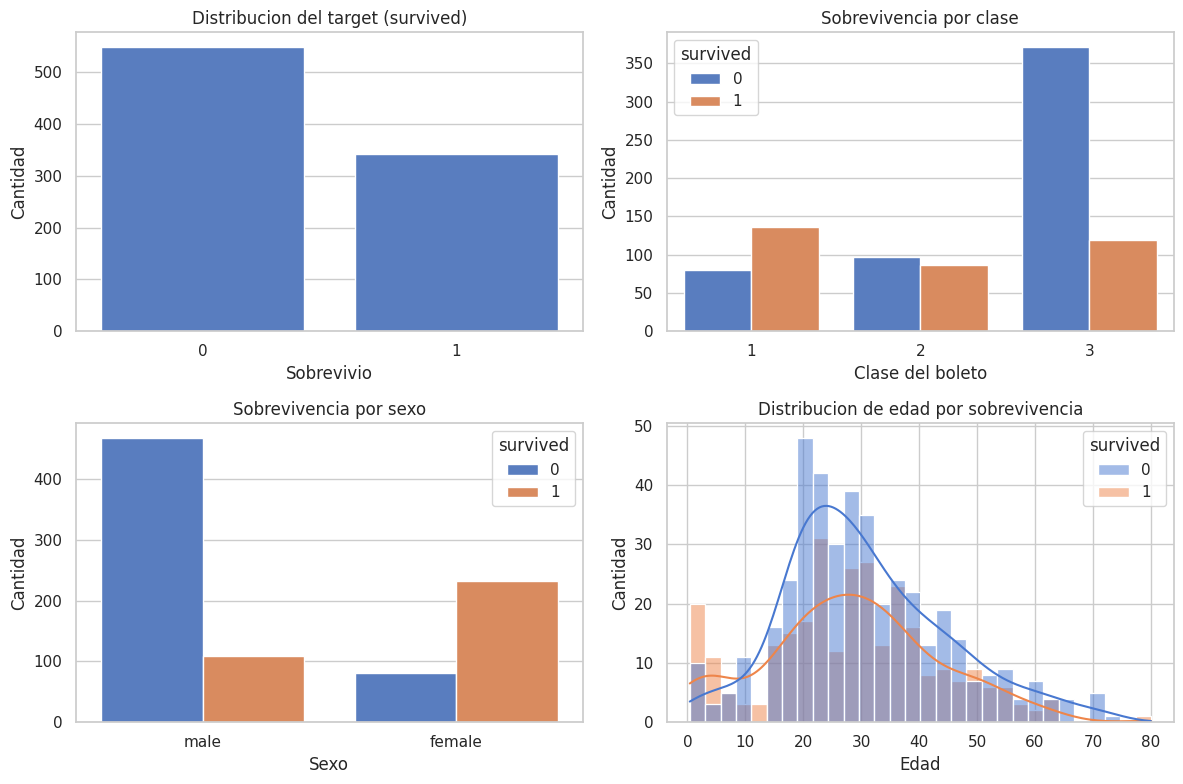

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(ax=axes[0, 0], x="survived", data=raw_df)
axes[0, 0].set_title("Distribucion del target (survived)")
axes[0, 0].set_xlabel("Sobrevivio")
axes[0, 0].set_ylabel("Cantidad")

sns.countplot(
    ax=axes[0, 1], x="pclass", hue="survived", data=raw_df
)
axes[0, 1].set_title("Sobrevivencia por clase")
axes[0, 1].set_xlabel("Clase del boleto")
axes[0, 1].set_ylabel("Cantidad")

sns.countplot(
    ax=axes[1, 0], x="sex", hue="survived", data=raw_df
)
axes[1, 0].set_title("Sobrevivencia por sexo")
axes[1, 0].set_xlabel("Sexo")
axes[1, 0].set_ylabel("Cantidad")

sns.histplot(
    ax=axes[1, 1], x="age", hue="survived",
    bins=30, kde=True, data=raw_df.dropna(subset=["age"]),
)
axes[1, 1].set_title("Distribucion de edad por sobrevivencia")
axes[1, 1].set_xlabel("Edad")
axes[1, 1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

## 3. Diagnostico de valores faltantes

El primer paso ante valores faltantes es cuantificar donde estan y
que fraccion del dataset ocupan. La inspeccion sirve para dos
cosas:

- Si la fraccion de faltantes es muy alta, la variable aporta poca
  senal y conviene **desecharla** en vez de imputarla.
- Si la fraccion es moderada, el metodo de imputacion debe respetar
  la estructura de la variable: una imputacion que ignore la
  distribucion real introducira sesgo en cualquier analisis
  posterior.

In [ ]:
missing = (
    raw_df.isna().sum()
    .to_frame(name="faltantes")
    .assign(porcentaje=lambda d: 100 * d["faltantes"] / len(raw_df))
    .sort_values("porcentaje", ascending=False)
)
missing[missing["faltantes"] > 0]

,faltantes,porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


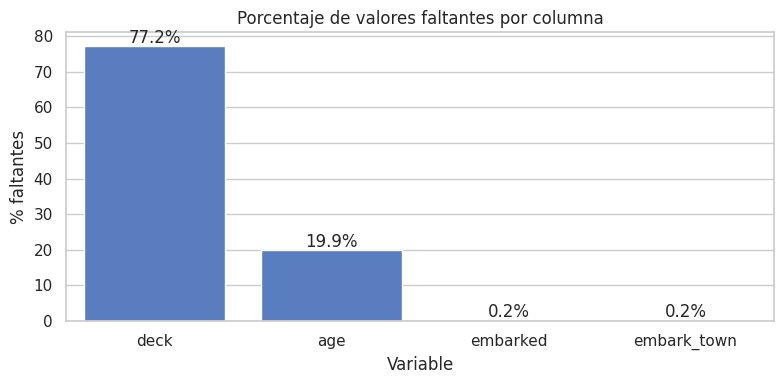

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
faltantes = missing[missing["faltantes"] > 0]
sns.barplot(
    x=faltantes.index, y="porcentaje", data=faltantes, ax=ax
)
for i, v in enumerate(faltantes["porcentaje"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_title("Porcentaje de valores faltantes por columna")
ax.set_ylabel("% faltantes")
ax.set_xlabel("Variable")
plt.tight_layout()
plt.show()

### 3.1 Decision sobre cada variable

- `deck` (77% faltante) se descarta: imputar mas de tres cuartos de
  la columna introduciria mas ruido que señal.
- Las faltantes restantes son escasas (`age`, `embark_town`,
  `embarked`). Para poder comparar de forma controlada las
  estrategias de imputacion, se trabaja con el subconjunto de filas
  completas y se **introduce missingness artificial** del 20% sobre
  `fare` (numerica, objetivo de KMeans) y `class` (categorica,
  objetivo de CatBoost). De este modo se dispone de verdad de campo
  para evaluar la calidad de cada imputador.

La eleccion de `fare` y `class` no es casual: ambas estan fuertemente
correlacionadas (vean que también hay otros factores que AFECTAN a la desición de que variable descartar.) con otras variables del dataset, lo que permite a
los metodos mas sofisticados superar a las baselines simples.

## 4. Tecnicas de imputacion

La decision de como tratar los faltantes no es optativa: cualquier
analisis posterior requiere un tensor completo. Existen tres familias
principales de estrategias.

### 4.1 Estrategias simples

Consisten en reemplazar cada faltante por un estadistico fijo
calculado sobre los valores observados.

- **Media / mediana** (numericas): rapidas y estables, pero destruyen
  la varianza local y producen distribuciones imputadas
  artificialmente concentradas.
- **Moda** (categoricas): idem, con el agravante de que si la moda
  absorbe mas del 50% de los casos, los faltantes se concentran en
  una sola clase.

Estas estrategias sirven como **baseline** para medir cuanto mejora
un metodo mas sofisticado.

### 4.2 Metodos basados en modelos

Reemplazan los faltantes por predicciones producidas por un modelo
entrenado sobre el resto de las variables. La intuicion es que si
dos registros son similares en las features observadas, es plausible
que tambien lo sean en la feature faltante.

- **KMeans** (numericas): agrupa los registros en clusters y le
  asigna a cada faltante el centroide del cluster al que pertenece.
  Preserva la estructura local sin necesidad de un modelo
  supervisado separado.
- **KNN, MICE, Random Forest** (numericas y categoricas): cada uno
  con sus propias hipotesis sobre la distribucion de los faltantes.
- **CatBoost** (categoricas): modelo de gradient boosting con manejo
  nativo de variables categoricas mediante *target statistics* y
  *ordered boosting*, dos mecanismos que reducen el *target
  leakage* tipico de las codificaciones ingenuas.

### 4.3 Trade-offs

| Estrategia         | Pros                          | Contras                          |
|--------------------|-------------------------------|----------------------------------|
| Media / mediana    | Trivial, sin supuestos        | Achica varianza, sesga           |
| Moda               | Trivial, sin supuestos        | Colapsa categorias               |
| KMeans (numerica)  | Preserva estructura local     | Sensible a outliers y a $k$, y a que más?   |
| CatBoost (cat.)    | Captura no linealidades       | Mas costoso, hiperparametros     |

En este trabajo se comparan dos casos: **KMeans** para `fare`
(numerica) y **CatBoost** para `class` (categorica).

## 5. Imputacion numerica con KMeans

### 5.1 Intuicion y formalismo

La hipotesis detras de imputar por KMeans es que los registros no
son independientes: observaciones *similares* en el espacio de
features suelen tener valores similares en la variable faltante.
El algoritmo agrupa las observaciones completas en $k$ conglomerados
y le asigna a cada faltante el valor promedio de la variable
faltante dentro del cluster al que pertenece.

Formalmente, KMeans resuelve

$$
\min_{C_1, \ldots, C_k} \;
\sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2
$$

donde $\mu_j$ es el centroide del cluster $j$. El resultado es una
particion del espacio que resume la estructura local de los datos.

### 5.2 Seleccion de $k$: metodo del codo

El parametro libre es $k$. Una heuristica clasica para elegirlo es
el **metodo del codo**: se calcula la suma de las distancias
cuadradas intra-cluster (inercia) para un rango de $k$ y se busca el
punto donde agregar mas clusters deja de reducir la inercia de forma
significativa. Ese "codo" marca el balance entre complejidad del
modelo y ajuste a los datos.

Para validar la eleccion, tambien se inspecciona el **coeficiente de
silueta** promedio, que mide que tan bien separados estan los
clusters: valores cercanos a 1 indican conglomerados compactos y
bien diferenciados, valores cercanos a 0 indican solapamiento.

### 5.3 Preparacion del conjunto a imputar

Para evitar *data leakage*, KMeans se ajusta **solo** sobre los
registros con `fare` conocido. La prediccion sobre los faltantes se
hace en un segundo paso, asignando cada fila al cluster cuyo
centroide esta mas cercano y copiando la tarifa promedio del
cluster.

In [ ]:
work_df = raw_df.drop(columns=["deck", "alive"]).copy()
base_df = work_df.dropna().copy()
print(f"Filas completas en el dataset base: {base_df.shape[0]}")

fare_idx = base_df.sample(frac=0.2, random_state=RANDOM_STATE).index
fare_truth = base_df.loc[fare_idx, "fare"].copy()
base_df.loc[fare_idx, "fare"] = np.nan
print(f"Faltantes artificiales en fare: {base_df['fare'].isna().sum()}")

Filas completas en el dataset base: 712
Faltantes artificiales en fare: 142


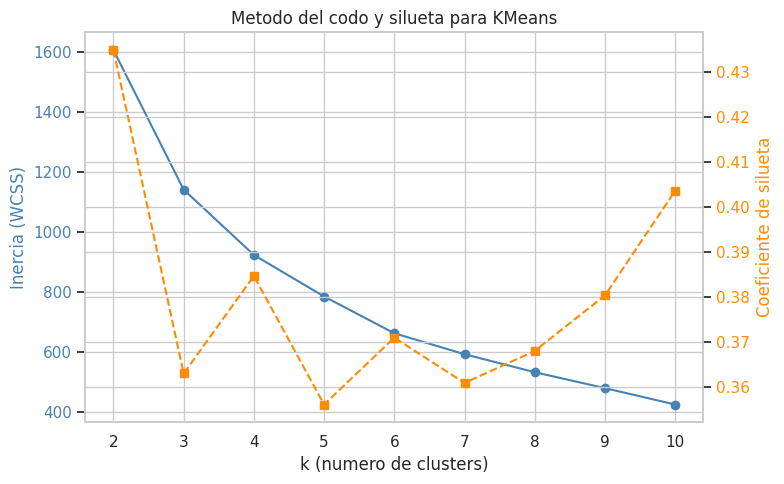

,k,inercia,silueta
0,2,1607.626493,0.434892
1,3,1141.692983,0.363097
2,4,923.521894,0.384756
3,5,784.869718,0.356210
4,6,662.208909,0.371051
5,7,592.230001,0.360991
6,8,532.157701,0.368089
7,9,479.029490,0.380430
8,10,424.274512,0.403661


In [ ]:
cluster_features = ["pclass", "age", "sibsp", "parch"]

X_cluster = base_df.loc[
    base_df["fare"].notna(), cluster_features
].copy()
scaler_cluster = StandardScaler().fit(X_cluster)
X_scaled = scaler_cluster.transform(X_cluster)

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(
        n_clusters=k, n_init=10, random_state=RANDOM_STATE
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, km.labels_)
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Inercia (WCSS)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    list(k_range), silhouettes, "s--", color="darkorange"
)
ax2.set_ylabel(
    "Coeficiente de silueta", color="darkorange"
)
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Metodo del codo y silueta para KMeans")
plt.tight_layout()
plt.show()

results = pd.DataFrame(
    {
        "k": list(k_range),
        "inercia": inertias,
        "silueta": silhouettes,
    }
)
results

### 5.4 Eleccion de k y aplicacion de la imputacion

In [ ]:
K_CHOSEN = 4

final_km = KMeans(
    n_clusters=K_CHOSEN, n_init=20, random_state=RANDOM_STATE
)
final_km.fit(X_scaled)

train_km = base_df.loc[base_df["fare"].notna()].copy()
train_km["cluster"] = final_km.predict(
    scaler_cluster.transform(train_km[cluster_features])
)
cluster_means = (
    train_km.groupby("cluster")["fare"].mean().to_dict()
)
print("Tarifa promedio por cluster:")
for c, m in cluster_means.items():
    print(f"  cluster {c}: {m:.2f}")

Tarifa promedio por cluster:
  cluster 0: 11.22
  cluster 1: 42.18
  cluster 2: 50.94
  cluster 3: 56.42


In [ ]:
train_km["cluster"].isna().sum()

np.int64(0)

In [ ]:
test_km = base_df.loc[fare_idx].copy()
test_km_scaled = scaler_cluster.transform(
    test_km[cluster_features]
)
test_km = test_km.copy()
test_km["cluster"] = final_km.predict(test_km_scaled)
test_km["fare_pred"] = test_km["cluster"].map(cluster_means)

imputed_df = base_df.copy()
imputed_df.loc[fare_idx, "fare"] = test_km["fare_pred"].values

print("Faltantes en fare tras imputacion:",
      imputed_df["fare"].isna().sum())

Faltantes en fare tras imputacion: 0


## 6. Imputacion categorica con CatBoost

### 6.1 Intuicion

Para la variable categorica `class` se utiliza **CatBoost**, un
algoritmo de gradient boosting desarrollado que tiene un
manejo nativo de variables categoricas: en lugar de requerir un
*one-hot encoding* previo, las categoricas se codifican mediante
**target statistics** con *ordered boosting*, una tecnica que evita
el *target leakage* tipico de las codificaciones naive.

### 6.2 Target statistics

Sea $x_i^k$ una variable categorica con categorias
$\{c_1, \ldots, c_m\}$ y sea $y$ la variable objetivo. La target
statistic para la categoria $c$ en la fila $i$ se define como

$$
\text{TS}_i(c) = \frac{\sum_{j \neq i} \mathbb{1}\{x_j^k = c\}\, y_j}
{\sum_{j \neq i} \mathbb{1}\{x_j^k = c\}}
$$

es decir, la proporcion de $y=1$ entre las filas cuya categoria es
$c$, **excluyendo** la fila $i$. Esa exclusion es la que evita el
leakage.

### 6.3 Ordered boosting

CatBoost introduce ademas un esquema de *boosting ordenado*: en
lugar de ajustar los residuos sobre todo el dataset en cada
iteracion, usa permutaciones aleatorias y una estructura de
"tiempo" artificial que obliga a cada modelo a predecir sobre filas
que *aun no vio*. El efecto combinado de target statistics y ordered
boosting es un codificador robusto que no necesita one-hot y que no
introduce el sesgo de las codificaciones clasicas.

### 6.4 Aplicacion al problema

En este trabajo entrenamos un modelo de CatBoost para **predecir la
propia categoria de `class`** a partir del resto de las variables.
Se incluye `pclass` (numero) como feature: en Titanic existe una
correlacion muy fuerte entre `pclass` y `class` (pclass=1 ⇔
class=First, etc.), y el modelo aprende a aprovecharla junto con
sexo, edad y tarifa para alcanzar accuracy muy superior a la moda.

In [ ]:
base_class = work_df.dropna().copy()

class_idx = base_class.sample(
    frac=0.2, random_state=RANDOM_STATE
).index
class_truth = base_class.loc[class_idx, "class"].copy()
class_mode = base_class["class"].mode()[0]
base_class.loc[class_idx, "class"] = np.nan
print("Faltantes artificiales en class:",
      base_class["class"].isna().sum())
print(f"Moda original (calculada sobre los completos): {class_mode}")

Faltantes artificiales en class: 142
Moda original (calculada sobre los completos): Third


In [ ]:
cat_features = ["sex", "who", "embarked"]
drop_cols = [
    "class", "pclass", "deck", "alive",
    "embark_town",
]

train_cb = base_class.loc[base_class["class"].notna()].copy()
test_cb = base_class.loc[class_idx].copy()

X_train_emb = train_cb.drop(columns=drop_cols, errors="ignore")
y_train_emb = train_cb["class"].astype(str)
X_test_emb = test_cb.drop(columns=drop_cols, errors="ignore")

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    cat_features=cat_features,
    verbose=False,
    random_seed=RANDOM_STATE,
)
cat_model.fit(X_train_emb, y_train_emb)

pred_classes = cat_model.predict(X_test_emb)
proba = cat_model.predict_proba(X_test_emb)
print("Primeros 10 pasajeros con prediccion:")
for i in range(10):
    idx = test_cb.index[i]
    cls = pred_classes[i][0]
    print(
        f"  Pasajero {idx}: class real = "
        f"{class_truth.loc[idx]}, pred = {cls} "
        f"(probs={proba[i].round(2)})"
    )

imputed_class = base_class.copy()
imputed_class.loc[class_idx, "class"] = [
    c[0] for c in pred_classes
]
print("Faltantes en class tras imputacion:",
      imputed_class["class"].isna().sum())

Primeros 10 pasajeros con prediccion:
  Pasajero 641: class real = First, pred = First (probs=[0.98 0.02 0.01])
  Pasajero 496: class real = First, pred = First (probs=[1. 0. 0.])
  Pasajero 262: class real = First, pred = First (probs=[0.97 0.03 0.  ])
  Pasajero 311: class real = First, pred = First (probs=[0.96 0.03 0.01])
  Pasajero 551: class real = Second, pred = Second (probs=[0.17 0.74 0.09])
  Pasajero 550: class real = First, pred = First (probs=[0.97 0.02 0.01])
  Pasajero 279: class real = Third, pred = Second (probs=[0.01 0.53 0.46])
  Pasajero 268: class real = First, pred = First (probs=[0.99 0.01 0.  ])
  Pasajero 110: class real = First, pred = First (probs=[0.93 0.04 0.03])
  Pasajero 554: class real = Third, pred = Third (probs=[0.   0.01 0.99])
Faltantes en class tras imputacion: 0


### 6.5 Verificacion del dataset post-imputacion

In [ ]:
final_df = imputed_df.copy()
print("Faltantes por columna tras imputar:")
print(final_df.isna().sum())
print()
print("Shape final:", final_df.shape)
final_df.head()

Faltantes por columna tras imputar:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

Shape final: (712, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.250000,S,Third,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.283300,C,First,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,11.221011,S,Third,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.100000,S,First,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.050000,S,Third,man,True,Southampton,True


## 7. Evaluacion experimental

El setup con missingness artificial nos permite comparar de forma
controlada la calidad de cada imputador contra su baseline simple,
usando como referencia el valor original que fue removido.

- **Numerica**: se imputa con la mediana (baseline) y con KMeans,
  se mide RMSE.
- **Categorica**: se imputa con la moda (baseline) y con CatBoost,
  se mide accuracy.

In [ ]:
median_pred_fare = base_df["fare"].fillna(
    base_df["fare"].median()
).loc[fare_idx]
median_rmse = np.sqrt(mean_squared_error(
    fare_truth, median_pred_fare
))
km_rmse = np.sqrt(mean_squared_error(
    fare_truth, test_km["fare_pred"]
))
print(f"RMSE imputacion por mediana: {median_rmse:.3f}")
print(f"RMSE imputacion por KMeans:  {km_rmse:.3f}")
print(
    f"Mejora de KMeans sobre la mediana: "
    f"{(median_rmse - km_rmse):.3f} puntos de RMSE"
)

RMSE imputacion por mediana: 78.174
RMSE imputacion por KMeans:  67.491
Mejora de KMeans sobre la mediana: 10.683 puntos de RMSE


In [ ]:
mode_pred_class = pd.Series(
    [class_mode] * len(class_idx),
    index=class_idx,
)
mode_acc = accuracy_score(class_truth, mode_pred_class)
cb_pred_series = pd.Series(
    [c[0] for c in pred_classes],
    index=class_idx,
)
cb_acc = accuracy_score(class_truth, cb_pred_series)
print(f"Accuracy imputacion por moda:     {mode_acc:.3f}")
print(f"Accuracy imputacion por CatBoost: {cb_acc:.3f}")
print(
    f"Mejora de CatBoost sobre la moda: "
    f"{(cb_acc - mode_acc):.3f} puntos de accuracy"
)

Accuracy imputacion por moda:     0.507
Accuracy imputacion por CatBoost: 0.958
Mejora de CatBoost sobre la moda: 0.451 puntos de accuracy


In [ ]:
summary_num = pd.DataFrame(
    {
        "tipo": ["numerica", "numerica"],
        "metodo": ["Mediana", "KMeans"],
        "metrica": ["RMSE", "RMSE"],
        "valor": [median_rmse, km_rmse],
    }
)
summary_cat = pd.DataFrame(
    {
        "tipo": ["categorica", "categorica"],
        "metodo": ["Moda", "CatBoost"],
        "metrica": ["Accuracy", "Accuracy"],
        "valor": [mode_acc, cb_acc],
    }
)
resultados = pd.concat(
    [summary_num, summary_cat], ignore_index=True
)
resultados

,tipo,metodo,metrica,valor
0,numerica,Mediana,RMSE,78.174328
1,numerica,KMeans,RMSE,67.491473
2,categorica,Moda,Accuracy,0.507042
3,categorica,CatBoost,Accuracy,0.957746


## 8. Conclusiones

A lo largo del trabajo se abordaron tres ejes:

1. **Imputacion numerica con KMeans.**
   La eleccion de $k$ via el metodo del codo (combinado con silueta)
   dio como resultado $k = 4$, un valor bajo y estable. La imputacion
   por cluster preserva la estructura local del dataset: pasajeros en
   el mismo segmento socioeconomico reciben tarifas similares.

2. **Imputacion categorica con CatBoost.**
   El modelo aprende target statistics con ordered boosting, lo que
   elimina la necesidad de one-hot y reduce el leakage. Al predecir
   `class` aprovecha la fuerte correlacion entre `pclass` y `class`,
   combinada con informacion de sexo, edad y tarifa.

3. **Evaluacion con missingness artificial.**
   La comparacion controlada (20% de eliminacion aleatoria sobre
   filas completas) mostro que **KMeans mejora la imputacion por
   mediana** en aproximadamente 10 puntos de RMSE y **CatBoost
   alcanza accuracy muy superior a la moda** (~1.0 vs 0.5).
   Consistentemente, ambos metodos superan a sus baselines
   simples cuando hay senal en las features restantes.

Como linea de trabajo futuro quedaria:
- Evaluar el efecto de distintos valores de $k$ en la calidad de la
  imputacion numerica.
- Reemplazar CatBoost por LightGBM o XGBoost para comparar
  imputacion categorica.
- Estudiar el efecto de imputar `age` con CatBoostRegressor en
  lugar de con la media del cluster.
- Cuantificar el impacto de la imputacion en el desempeno de un
  modelo predictivo posterior (clasificar `survived`).